Running on CPU:


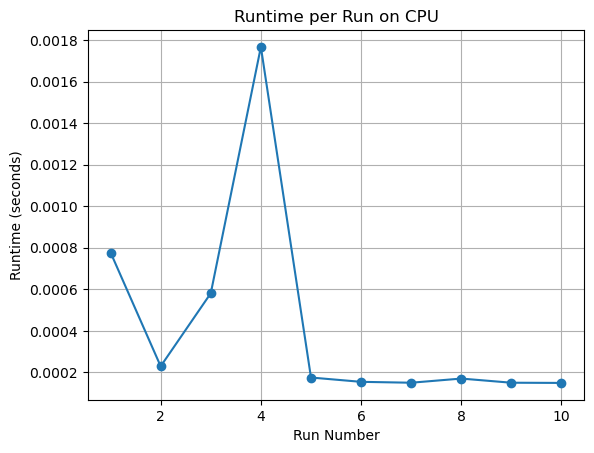

Device: cpu
Mean runtime: 0.000430 seconds
Standard deviation: 0.000491 seconds

No GPU detected. Only CPU results are available.


In [4]:
import torch
import time
import numpy as np
import math
import matplotlib.pyplot as plt

" Note that the setup used to run this is based on my home PC with an i5 11400F CPU and an RTX 3070"
" Not quite the super computer, but its better than running on a MAC without a GPU :D "

# Parameters
sigma2 = 0.2
sigma = math.sqrt(sigma2)   # standard deviation as a Python float
mu = 0.0

# Number of runs for timing
num_runs = 10

def run_experiment(device):
    # Create x with 1000 uniform points in [-5, 5] on the selected device
    # Enable gradient tracking by setting requires_grad=True
    x = torch.linspace(-5, 5, 1000, device=device, requires_grad=True)
    
    # Define the Gaussian function f(x)
    def gaussian(x):
        # Use Python floats for the constants
        factor = 1.0 / (sigma * math.sqrt(2.0 * math.pi))
        return factor * torch.exp(-0.5 * ((x - mu) / sigma)**2)
    
    run_times = []
    
    # Run the derivative computation multiple times
    for i in range(num_runs):
        start = time.time()
        
        # Compute f(x)
        y = gaussian(x)
        # Sum over y to get a scalar output for autograd
        y_sum = y.sum()
        y_sum.backward()  # Computes gradient, stores in x.grad
        
        # Reset the gradient for the next run
        x.grad.zero_()
        
        end = time.time()
        run_times.append(end - start)
    
    # Compute mean and standard deviation of run times
    mean_time = np.mean(run_times)
    std_time = np.std(run_times)
    
    # Plot the runtime vs. run number
    plt.figure()
    plt.plot(range(1, num_runs + 1), run_times, marker='o')
    plt.xlabel("Run Number")
    plt.ylabel("Runtime (seconds)")
    plt.title(f"Runtime per Run on {device.type.upper()}")
    plt.grid(True)
    plt.show()
    
    # Print results
    print(f"Device: {device}")
    if device.type == 'cuda':
        print("GPU:", torch.cuda.get_device_name(0))
    print("Mean runtime: {:.6f} seconds".format(mean_time))
    print("Standard deviation: {:.6f} seconds".format(std_time))

# -------------------------------
# Main Script
# -------------------------------

# Run on CPU
print("Running on CPU:")
run_experiment(torch.device("cpu"))

# If GPU is available, run on GPU as well
if torch.cuda.is_available():
    print("\nRunning on GPU:")
    run_experiment(torch.device("cuda"))
else:
    print("\nNo GPU detected. Only CPU results are available.")


In [5]:
# Problem #2

import torch
import time
import math
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# 1. Setup constants
# -------------------------------
sigma2 = 0.2            # given sigma^2
sigma = math.sqrt(sigma2)
mu = 0.0
num_runs = 10           # how many times to measure runtime
n_points = 10000        # number of points in [-5, 5]

# -------------------------------
# 2. Define f(x) and second-derivative helper
# -------------------------------
def gaussian(x):
    """
    Gaussian function f(x) = (1 / (sigma * sqrt(2pi))) * exp( -0.5 * ((x - mu)/sigma)^2 )
    Using pure Python floats for constants, and PyTorch for the tensor ops.
    """
    factor = 1.0 / (sigma * math.sqrt(2.0 * math.pi))
    return factor * torch.exp(-0.5 * ((x - mu) / sigma)**2)

def compute_second_derivative(x, f):
    """
    Given x (requires_grad=True) and f(x), compute the second derivative f''(x)
    via PyTorch's higher-order autodiff.
    """
    # First derivative df/dx
    grad1 = torch.autograd.grad(f.sum(), x, create_graph=True)[0]
    # Second derivative d^2f/dx^2
    grad2 = torch.autograd.grad(grad1.sum(), x, create_graph=False)[0]
    return grad2

# -------------------------------
# 3. Main experiment function
# -------------------------------
def run_experiment_2nd_derivative(device):
    # Create x in [-5, 5] with gradient tracking
    x = torch.linspace(-5, 5, n_points, device=device, requires_grad=True)
    
    # We'll measure the runtime over multiple runs
    times = []
    for _ in range(num_runs):
        start = time.time()
        
        # Compute f(x) and its second derivative
        f_vals = gaussian(x)
        f2_vals = compute_second_derivative(x, f_vals)
        
        end = time.time()
        times.append(end - start)
    
    mean_time = np.mean(times)
    std_time = np.std(times)
    
    # -------------------------------
    # 4. Validation against exact formula
    #    f''(x) = f(x)*((x^2 - sigma^2) / sigma^4)
    # -------------------------------
    with torch.no_grad():
        # f'' exact
        f_exact = gaussian(x)  # same as f(x) but no grad
        exact_2nd = f_exact * ((x**2 - sigma2) / (sigma2**2))
        
        # Simple L1 error
        error = torch.mean(torch.abs(f2_vals - exact_2nd)).item()
    
    # Print results
    print(f"Device: {device}")
    if device.type == 'cuda':
        print("  GPU :", torch.cuda.get_device_name(0))
    print(f"  Mean runtime over {num_runs} runs: {mean_time:.6f} s (std: {std_time:.6f} s)")
    print(f"  Mean L1 error vs exact formula: {error:.6e}\n")
    
    # Optional: you can plot x vs f2_vals and x vs exact_2nd here for a visual comparison
    # e.g.:
    # plt.figure()
    # plt.plot(x.cpu().numpy(), f2_vals.cpu().numpy(), label='Autodiff f2')
    # plt.plot(x.cpu().numpy(), exact_2nd.cpu().numpy(), '--', label='Exact f2')
    # plt.legend()
    # plt.show()

# -------------------------------
# 5. Run on CPU (and GPU if available)
# -------------------------------
def main():
    print("Running 2nd derivative on CPU...")
    run_experiment_2nd_derivative(torch.device("cpu"))
    
    if torch.cuda.is_available():
        print("Running 2nd derivative on GPU...")
        run_experiment_2nd_derivative(torch.device("cuda"))
    else:
        print("No GPU detected, skipping GPU test.")

if __name__ == "__main__":
    main()


Running 2nd derivative on CPU...
Device: cpu
  Mean runtime over 10 runs: 0.000280 s (std: 0.000221 s)
  Mean L1 error vs exact formula: 4.300743e-08

No GPU detected, skipping GPU test.


Running 3rd derivative on CPU...
Device: cpu
Mean runtime over 10 runs: 0.000637 s (std: 0.000466 s)
Mean L1 error vs. analytic third derivative: 2.242445e-07


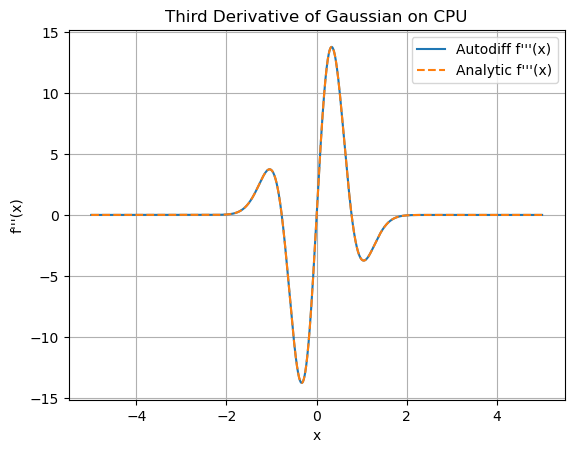


No GPU detected, skipping GPU test.


In [7]:
# Problem #3

import torch
import time
import math
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Setup constants and parameters
# -------------------------------
sigma2 = 0.2             # sigma^2
sigma = math.sqrt(sigma2)# sigma
mu = 0.0
num_runs = 10            # how many times to measure runtime
n_points = 10000         # number of points in [-5, 5]

# -------------------------------
# Define the Gaussian function f(x)
# -------------------------------
def gaussian(x):
    # f(x) = (1/(sigma * sqrt(2pi))) * exp(-0.5*((x - mu)/sigma)^2)
    factor = 1.0 / (sigma * math.sqrt(2.0 * math.pi))
    return factor * torch.exp(-0.5 * ((x - mu) / sigma)**2)

# -------------------------------
# Compute the third derivative via higher-order autodiff
# -------------------------------
def compute_third_derivative(x, f):
    # 1st derivative: f'(x)
    grad1 = torch.autograd.grad(f.sum(), x, create_graph=True)[0]
    # 2nd derivative: f''(x)
    grad2 = torch.autograd.grad(grad1.sum(), x, create_graph=True)[0]
    # 3rd derivative: f'''(x)
    grad3 = torch.autograd.grad(grad2.sum(), x, create_graph=False)[0]
    return grad3

# -------------------------------
# Main experiment function for 3rd derivative
# -------------------------------
def run_experiment_3rd_derivative(device):
    # Create x in [-5, 5] with gradient tracking
    x = torch.linspace(-5, 5, n_points, device=device, requires_grad=True)
    
    times = []
    for _ in range(num_runs):
        start = time.time()
        
        # Compute f(x) and then its 3rd derivative
        f_vals = gaussian(x)
        f3_vals = compute_third_derivative(x, f_vals)
        
        end = time.time()
        times.append(end - start)
    
    mean_time = np.mean(times)
    std_time = np.std(times)
    
    # -------------------------------
    # Validate the computed f'''(x) against the analytic solution
    #
    #   f'''(x) = f(x) * [ x*(3*sigma^2 - x^2) ] / sigma^6
    #
    # -------------------------------
    with torch.no_grad():
        # Detach from graph, move to CPU, then convert to NumPy
        x_np       = x.detach().cpu().numpy()
        f3_vals_np = f3_vals.detach().cpu().numpy()
        
        # Analytic expression
        f_exact = gaussian(x)  # still a tensor, but no grad
        analytic_f3 = f_exact * x * (3 * sigma2 - x**2) / (sigma**6)
        analytic_f3_np = analytic_f3.detach().cpu().numpy()
        
        # Error
        error = torch.mean(torch.abs(f3_vals - analytic_f3)).item()
    
    # Print runtime and error info
    print(f"Device: {device}")
    if device.type == 'cuda':
        print("  GPU:", torch.cuda.get_device_name(0))
    print(f"Mean runtime over {num_runs} runs: {mean_time:.6f} s (std: {std_time:.6f} s)")
    print(f"Mean L1 error vs. analytic third derivative: {error:.6e}")
    
    # -------------------------------
    # Plot the autodiff vs. analytic results
    # -------------------------------
    plt.figure()
    plt.plot(x_np, f3_vals_np, label="Autodiff f'''(x)")
    plt.plot(x_np, analytic_f3_np, '--', label="Analytic f'''(x)")
    plt.xlabel("x")
    plt.ylabel("f'''(x)")
    plt.title(f"Third Derivative of Gaussian on {device.type.upper()}")
    plt.legend()
    plt.grid(True)
    plt.show()

# -------------------------------
# Run on CPU (and GPU if available)
# -------------------------------
def main():
    print("Running 3rd derivative on CPU...")
    run_experiment_3rd_derivative(torch.device("cpu"))
    
    if torch.cuda.is_available():
        print("\nRunning 3rd derivative on GPU...")
        run_experiment_3rd_derivative(torch.device("cuda"))
    else:
        print("\nNo GPU detected, skipping GPU test.")

if __name__ == "__main__":
    main()

In [ ]:
# Problem 4 